In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [10]:
df = pd.read_csv("Sample - Superstore.csv",encoding='latin1')

In [11]:
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
print("Dataset Shape:", df.shape)

Dataset Shape: (9994, 21)


In [13]:
print(df.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [14]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

#Create a column "days_to_ship"
df['days_to_ship'] = (df['Ship Date'] - df['Order Date']).dt.days

display(df[['Order Date', 'Ship Date', 'days_to_ship']].head())

,Order Date,Ship Date,days_to_ship
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [16]:
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)

print("\n      Sales & Profit by Region:")
display(region_summary)


      Sales & Profit by Region:


,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


In [17]:
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)

print("\n        Sales & Profit by Category:")
display(category_summary)


        Sales & Profit by Category:


,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


In [18]:
subcat_summary = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)

print("\n     Sales & Profit by Sub-Category:")
display(subcat_summary)


     Sales & Profit by Sub-Category:


,Sales,Profit
Sub-Category,,
Copiers,149528.0300,55617.8249
Phones,330007.0540,44515.7306
Accessories,167380.3180,41936.6357
Paper,78479.2060,34053.5693
Binders,203412.7330,30221.7633
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Appliances,107532.1610,18138.0054
Furnishings,91705.1640,13059.1436


In [19]:
top5 = subcat_summary.head(5)

print("\n   Top 5 Sub-Categories by Profit:")

display(top5)


   Top 5 Sub-Categories by Profit:


,Sales,Profit
Sub-Category,,
Copiers,149528.030,55617.8249
Phones,330007.054,44515.7306
Accessories,167380.318,41936.6357
Paper,78479.206,34053.5693
Binders,203412.733,30221.7633


In [20]:
bottom5 = subcat_summary.tail(5)

print("\n  Bottom 5 Sub-Categories by Profit:")

display(bottom5)


  Bottom 5 Sub-Categories by Profit:


,Sales,Profit
Sub-Category,,
Machines,189238.6310,3384.7569
Fasteners,3024.2800,949.5182
Supplies,46673.5380,-1189.0995
Bookcases,114879.9963,-3472.5560
Tables,206965.5320,-17725.4811


In [21]:
negative_profit = subcat_summary[subcat_summary['Profit'] < 0]

print("\n  Sub-Categories with Negative Profit:")

display(negative_profit)


  Sub-Categories with Negative Profit:


,Sales,Profit
Sub-Category,,
Supplies,46673.5380,-1189.0995
Bookcases,114879.9963,-3472.5560
Tables,206965.5320,-17725.4811


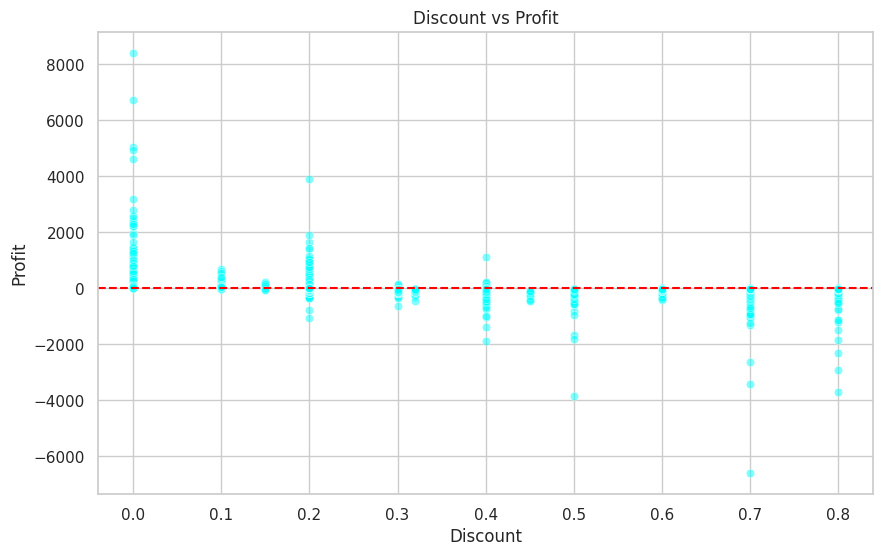

In [22]:
plt.figure()
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5,color='aqua')
plt.axhline(0, linestyle='--',color='red')
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

In [23]:
df['Year'] = df['Order Date'].dt.year

yearly_sales = df[df['Year'].between(2014, 2017)].groupby('Year')['Sales'].sum()

print("\nYearly Sales (2014–2017):")
display(yearly_sales)


Yearly Sales (2014–2017):


,Sales
Year,
2014,484247.4981
2015,470532.5090
2016,609205.5980
2017,733215.2552


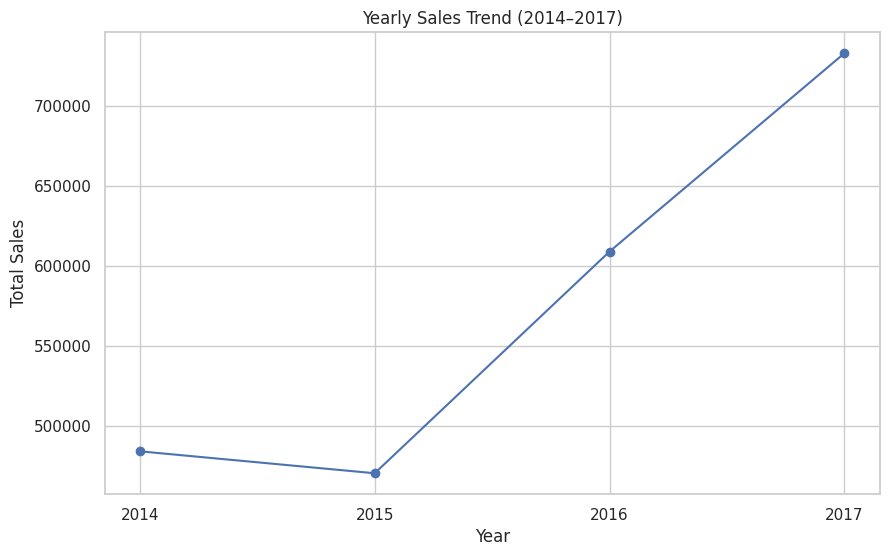

In [24]:
plt.figure()
plt.plot(yearly_sales.index, yearly_sales.values, marker='o')
plt.title("Yearly Sales Trend (2014–2017)")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(yearly_sales.index)
plt.show()

In [25]:
subcat_sorted = subcat_summary.sort_values(by='Profit')
display(subcat_sorted)

,Sales,Profit
Sub-Category,,
Tables,206965.5320,-17725.4811
Bookcases,114879.9963,-3472.5560
Supplies,46673.5380,-1189.0995
Fasteners,3024.2800,949.5182
Machines,189238.6310,3384.7569
Labels,12486.3120,5546.2540
Art,27118.7920,6527.7870
Envelopes,16476.4020,6964.1767
Furnishings,91705.1640,13059.1436


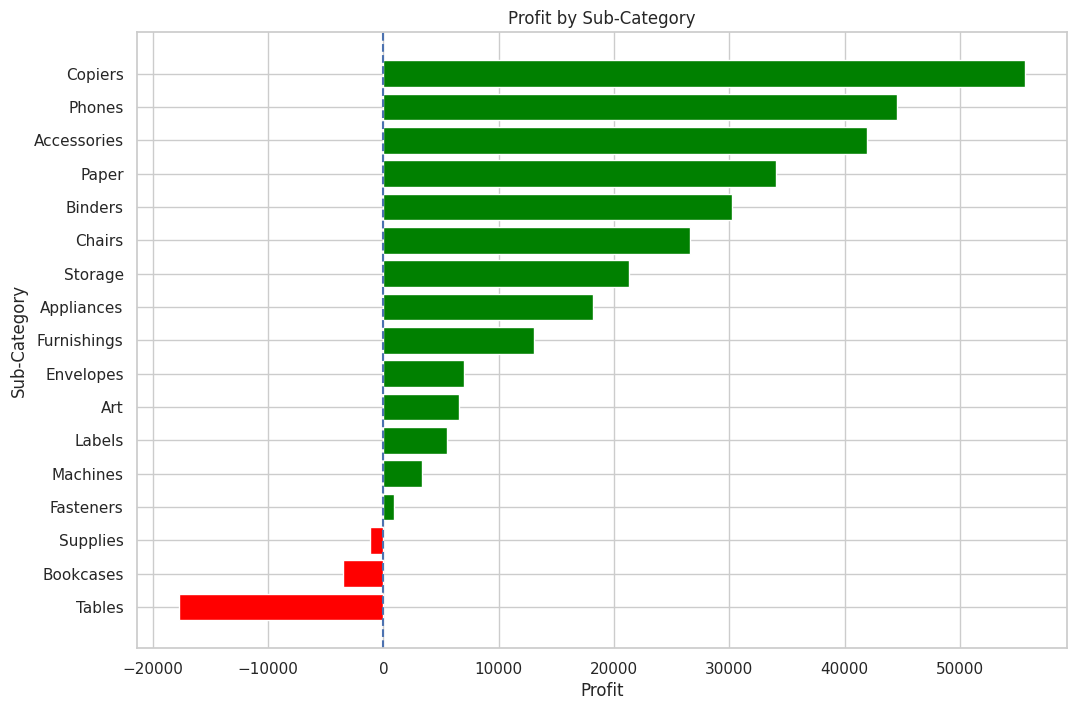

In [26]:
colors = ['red' if val < 0 else 'green' for val in subcat_sorted['Profit']]

plt.figure(figsize=(12, 8))
plt.barh(subcat_sorted.index, subcat_sorted['Profit'], color=colors)
plt.axvline(0, linestyle='--')
plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")
plt.show()

In [36]:
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum()


category_summary['Profit Margin (%)'] = (category_summary['Profit'] / category_summary['Sales']) * 100

print("\n                Profit Margin (%) by Category:")
display(category_summary)


                Profit Margin (%) by Category:


,Sales,Profit,Profit Margin (%)
Category,,,
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158
Technology,836154.0330,145454.9481,17.395712


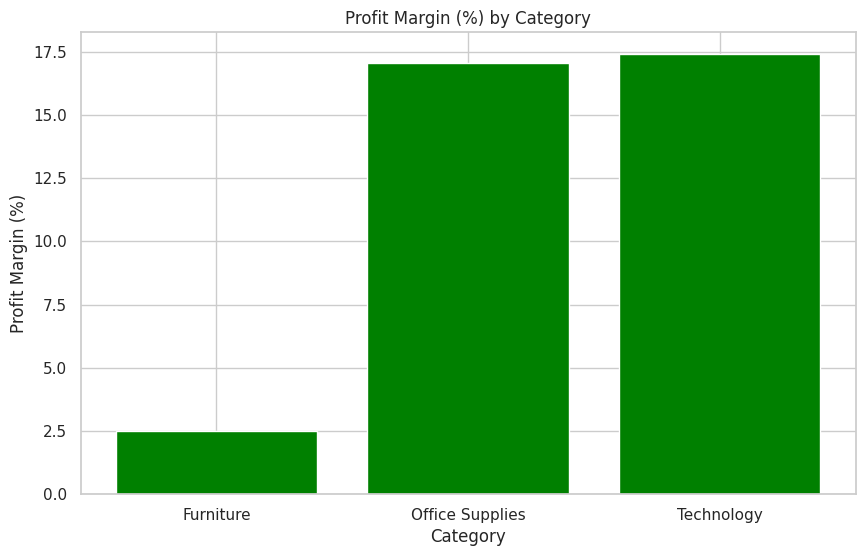

In [30]:
margin_colors = ['green' if val >= 0 else 'red' for val in category_summary['Profit Margin (%)']]

plt.figure()
plt.bar(category_summary.index, category_summary['Profit Margin (%)'], color=margin_colors)
plt.title("Profit Margin (%) by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.show()

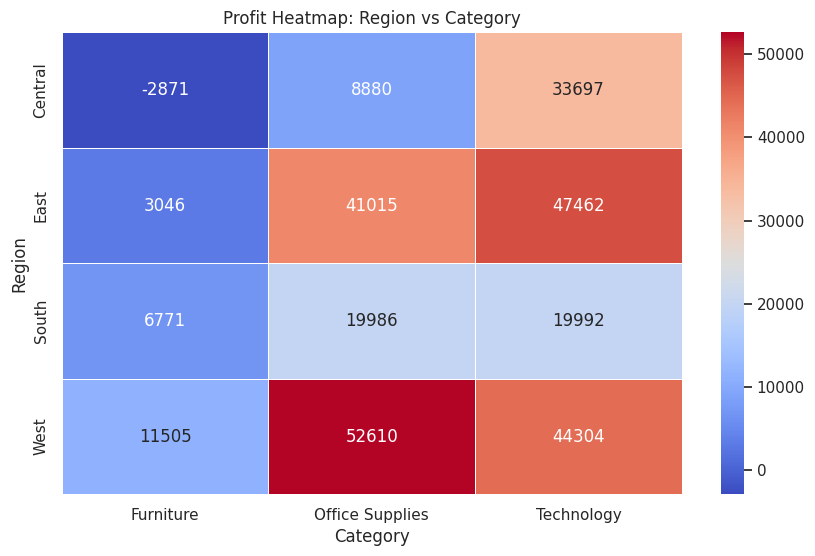

In [33]:
heatmap_data = df.pivot_table(values='Profit', index='Region', columns='Category', aggfunc='sum')

plt.figure()
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap='coolwarm', linewidths=0.5)
plt.title("Profit Heatmap: Region vs Category")
plt.xlabel("Category")
plt.ylabel("Region")
plt.show()